# 📘 Clase 3 · Notebook 7 — SARIMA: modelar la estacionalidad

**Curso de Machine Learning · Time Series Forecasting**
Basado en *Time Series Forecasting in Python* (Marco Peixeiro), **Capítulo 8**.

| | |
|---|---|
| **Datos** | `air-passengers.csv` — pasajeros aéreos mensuales de una aerolínea, ene-1949 a dic-1960 (144 meses) |
| **Tiempo estimado en casa** | 40 min (sin las búsquedas en malla; con ellas, bastante más) |
| **¿Se vio en clase?** | ✅ Sí — **Demo 5** (Bloque 3), sin ejecutar las búsquedas en malla |

### 🎯 Al terminar este notebook podrás…
1. Reconocer estacionalidad en un gráfico y con la **descomposición STL**.
2. Entender los parámetros de **SARIMA(p,d,q)(P,D,Q)m** y la **diferenciación estacional**.
3. Comparar *naive* estacional vs. ARIMA vs. SARIMA.

---

### ▶️ Cómo ejecutarlo

**En tu computador:** abre este notebook **desde su propia carpeta** (`CH08/`). Los datos se leen con la ruta relativa `../data/…`, así que si lo mueves de carpeta la lectura fallará.

**En Google Colab:** crea una celda al inicio y ejecuta:
```python
!git clone https://github.com/juandata-dev/TimeSeriesForecastingInPython.git
%cd TimeSeriesForecastingInPython/CH08
```

**Librerías:** `pandas`, `numpy`, `matplotlib`, `statsmodels`, `scikit-learn`, `tqdm`.
Si te falta alguna: `pip install statsmodels scikit-learn tqdm`.

### 🗺️ Leyenda de las anotaciones
| Ícono | Significa |
|---|---|
| 🧭 | Qué hace la siguiente celda |
| 🔎 | Cómo leer el resultado que acabas de obtener |
| 💡 | Intuición o analogía para entender el concepto |
| ⚠️ | Cuidado: error común o trampa |
| 🛠️ | Cambio que hicimos al código original del libro para que funcione con versiones recientes de las librerías |
| 🤔 | Pregunta para pensar antes de seguir |

> Las celdas en inglés con `#` son los títulos originales del libro. Las anotaciones en español son de la clase.


## 0. Librerías y concepto
💡 **SARIMA(p,d,q)(P,D,Q)m** = ARIMA + una segunda capa que opera **a la escala de la estación**.
- **m** → longitud del ciclo: 12 para datos mensuales con patrón anual, 4 para trimestrales, 7 para diarios con patrón semanal, 24 para horarios con patrón diario.
- **P, D, Q** → lo mismo que p, d, q pero mirando **m periodos atrás**: P valores de hace 12, 24… meses; D diferencias estacionales; Q sorpresas de hace 12, 24… meses.

Analogía: para pronosticar las ventas de diciembre, miras noviembre (parte no estacional, *p*) **y** el diciembre del año pasado (parte estacional, *P*).

In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm.auto import tqdm as tqdm_notebook  # 🛠️ tqdm.auto funciona en Jupyter, VS Code y Colab
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

🧭 Cargamos 144 meses de pasajeros.

In [4]:
df = pd.read_csv('../data/air-passengers.csv')
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


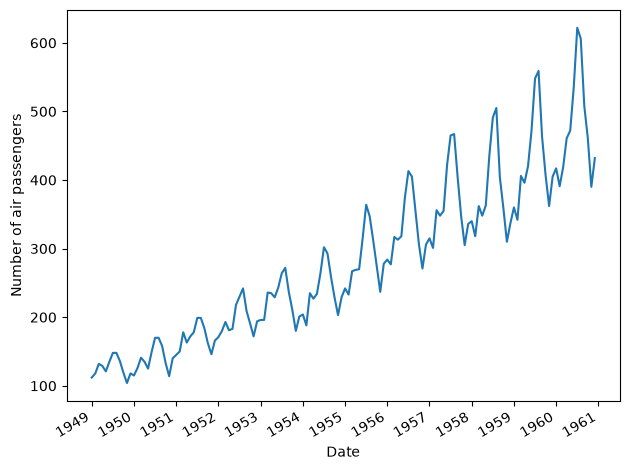

In [5]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH08_F01_peixeiro.png', dpi=300)

🔎 Tendencia creciente **y** picos que se repiten cada año, con amplitud creciente.

🧭 Marcamos con un punto el mes de **julio** de cada año para ver dónde caen los picos.

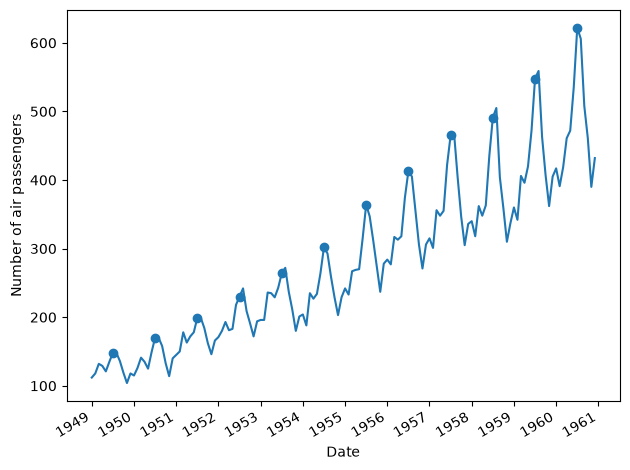

In [6]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'], markevery=np.arange(6, 145, 12), marker='o')
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH08_F02_peixeiro.png', dpi=300)

🔎 Los picos coinciden con mitad de año (vacaciones de verano en el hemisferio norte).

🧭 Líneas verticales al inicio de cada año: ¿el patrón se repite dentro de cada tramo?

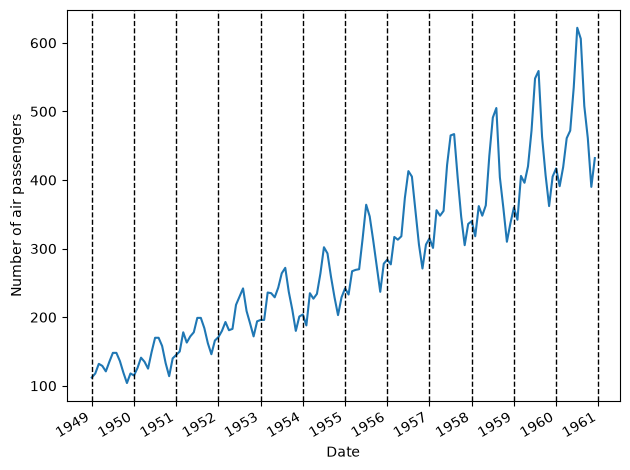

In [7]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
for i in np.arange(0, 145, 12):
    ax.axvline(x=i, linestyle='--', color='black', linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH08_F03_peixeiro.png', dpi=300)

💡 **Descomposición STL** (*Seasonal-Trend decomposition using LOESS*): separa la serie en
**observada = tendencia + estacionalidad + residuo**.
Analogía: separar una canción en batería (ritmo que se repite = estacionalidad), bajo (línea de fondo que sube = tendencia) y ruido de la grabación (residuo).

🧭 `period=12` porque los datos son mensuales con un ciclo anual.

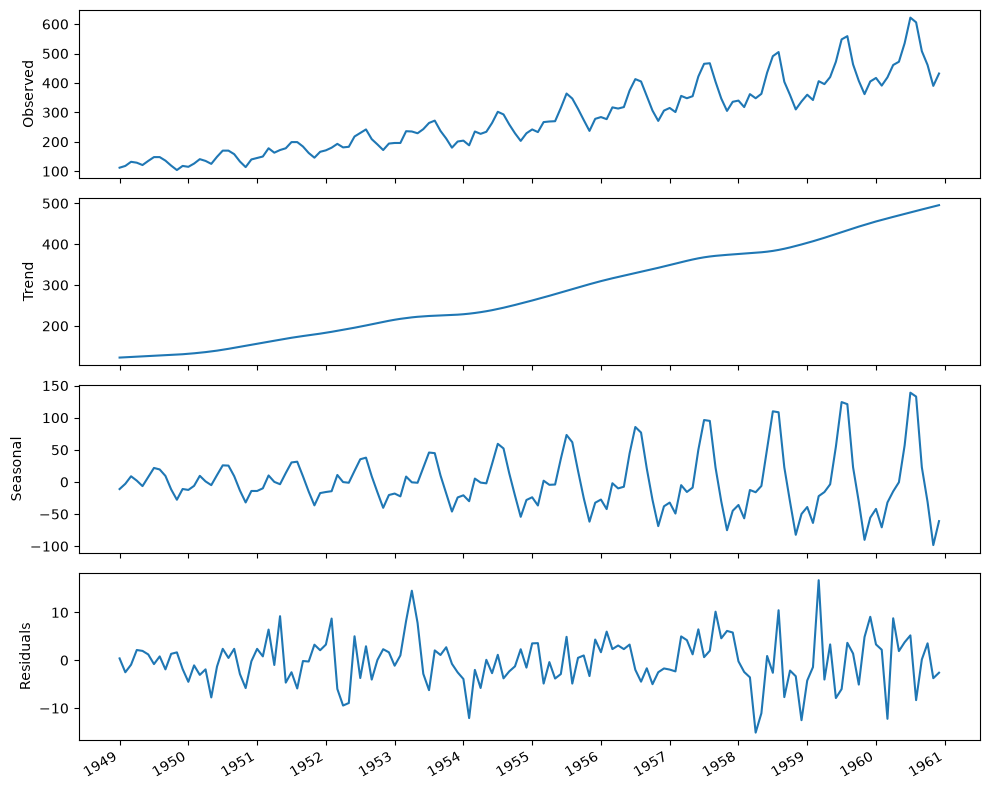

In [8]:
decomposition = STL(df['Passengers'], period=12).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH08_F04_peixeiro.png', dpi=300)

🔎 Panel **Seasonal**: un patrón claro que se repite cada 12 meses → hay estacionalidad. Panel **Trend**: crecimiento sostenido.

🧭 **Prueba de control:** descomponemos una recta perfecta (sin estacionalidad). Si STL funciona bien, el componente estacional debe salir plano en 0.

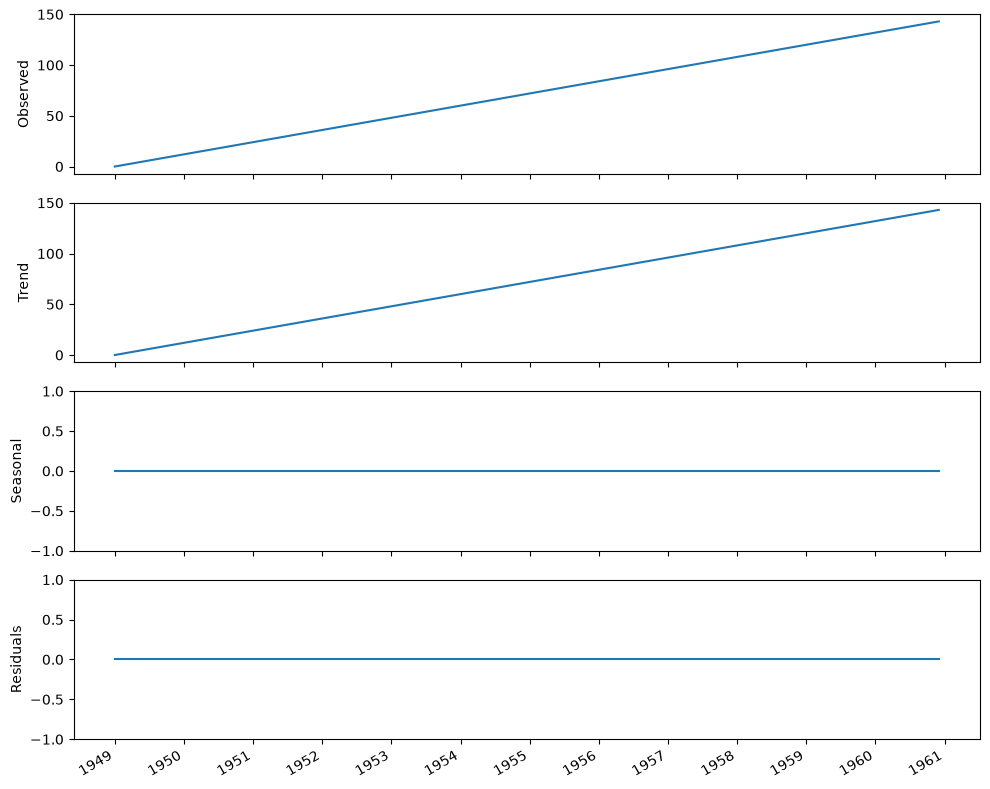

In [9]:
linear_ts = np.arange(0, 144, 1)

decomposition = STL(linear_ts, period=12).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')
ax3.set_ylim(-1, 1)

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')
ax4.set_ylim(-1, 1)

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH08_F05_peixeiro.png', dpi=300)

🔎 Estacionalidad y residuos ≈ 0: STL no inventa estacionalidad donde no la hay. ✅

🧭 Buscamos *d* y *D*: ADF sobre la serie original.

In [10]:
ad_fuller_result = adfuller(df['Passengers'])

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641


🔎 p ≈ 0.99 → no estacionaria.

In [11]:
df_diff = np.diff(df['Passengers'], n=1)

ad_fuller_result = adfuller(df_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -2.8292668241699994
p-value: 0.0542132902838255


🔎 Con una diferencia: p ≈ 0.054 → **apenas** por encima de 0.05: todavía no estacionaria.

In [13]:
# ✅ Diferencia estacional CORRECTA: y_t - y_{t-12} aplicada a la serie ya diferenciada una vez
df_diff_seasonal_correcta = df_diff[12:] - df_diff[:-12]

ad_fuller_result = adfuller(df_diff_seasonal_correcta)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -15.595618083746334
p-value: 1.8565116001234708e-28


🔎 Con la diferencia estacional correcta, el p-valor queda por debajo de 0.05 → la serie con **d = 1 y D = 1** es estacionaria, que es justo la configuración que usa el SARIMA más abajo.

In [14]:
df_diff2 = np.diff(df_diff, n=1)

ad_fuller_result = adfuller(df_diff2)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -16.384231542468505
p-value: 2.7328918500142407e-29


🔎 Con dos diferencias sí es estacionaria → para el **ARIMA** usaremos *d* = 2.

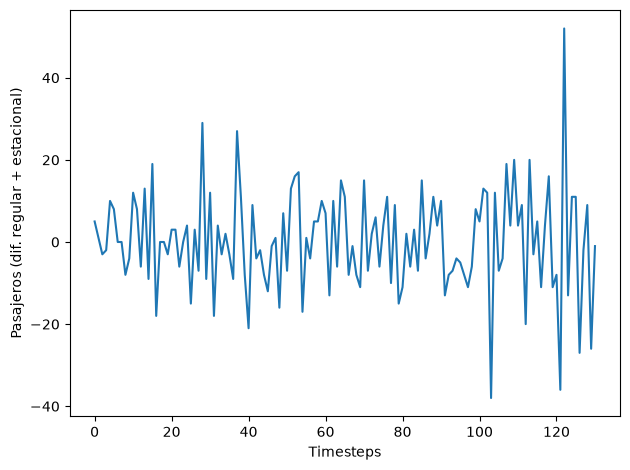

In [15]:
# 🛠️ El original graficaba una variable que no existe en este notebook (eps_diff_seasonal_diff,
# copiada del capítulo 7). Graficamos la serie con diferencia regular + estacional correcta.
fig, ax = plt.subplots()

ax.plot(df_diff_seasonal_correcta)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Pasajeros (dif. regular + estacional)')

plt.tight_layout()

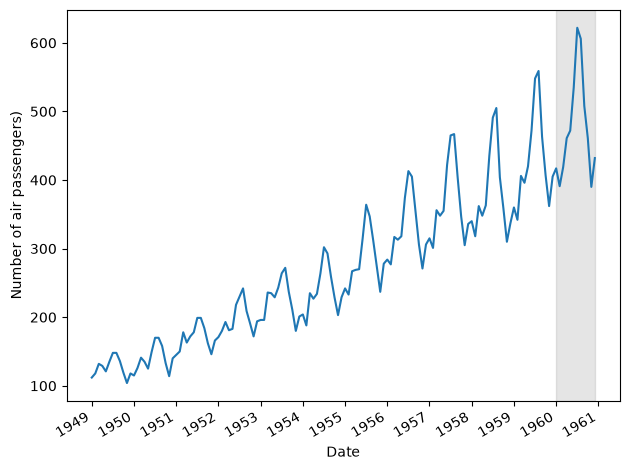

In [16]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers)')
ax.axvspan(132, 143, color='#808080', alpha=0.2)

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH08_F08_peixeiro.png', dpi=300)

🧭 Dos funciones de búsqueda en malla: una para ARIMA y otra para SARIMA (agrega P y Q).

In [17]:
def optimize_ARIMA(endog: Union[pd.Series, list], order_list: list, d: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(endog, order=(order[0], d, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [18]:
def optimize_SARIMA(endog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog, 
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

⏱️ **Esta celda es lenta.** La búsqueda en malla (*grid search*) ajusta un modelo por **cada** combinación de órdenes. Dejamos una bandera `EJECUTAR_BUSQUEDA = False` para que puedas seguir el notebook sin esperar: en ese caso se muestra el resultado ya conocido. Cuando tengas tiempo, cámbiala a `True` y compruébalo tú mismo.

🧭 Primero un ARIMA puro para comparar: p, q ∈ {0,…,12} con d = 2 → **169 modelos**.

In [19]:
EJECUTAR_BUSQUEDA = False   # ⏱️ True = 169 modelos, puede tardar bastante

train = df['Passengers'][:-12]

if EJECUTAR_BUSQUEDA:
    ps = range(0, 13, 1)
    qs = range(0, 13, 1)
    Ps = [0]
    Qs = [0]
    d = 2
    D = 0
    s = 12
    ARIMA_order_list = list(product(ps, qs, Ps, Qs))
    ARIMA_result_df = optimize_SARIMA(train, ARIMA_order_list, d, D, s)
else:
    print('Búsqueda omitida. Resultado conocido (libro, sección 8.3.1): mejor ARIMA = (p,d,q) = (11,2,3).')
    ARIMA_result_df = pd.DataFrame({'(p,q,P,Q)': [(11, 3, 0, 0)], 'AIC': ['ver libro']})
ARIMA_result_df

100%|██████████| 169/169 [01:21<00:00,  2.06it/s]


,"(p,q,P,Q)",AIC
0,"(11, 3, 0, 0)",1016.842003
1,"(11, 4, 0, 0)",1019.035466
2,"(11, 5, 0, 0)",1020.377994
3,"(12, 0, 0, 0)",1020.953542
4,"(11, 1, 0, 0)",1021.018746
...,...,...
164,"(5, 0, 0, 0)",1281.732157
165,"(3, 0, 0, 0)",1300.282335
166,"(2, 0, 0, 0)",1302.913196
167,"(1, 0, 0, 0)",1308.152194


⏱️ **Esta celda es lenta.** La búsqueda en malla (*grid search*) ajusta un modelo por **cada** combinación de órdenes. Dejamos una bandera `EJECUTAR_BUSQUEDA = False` para que puedas seguir el notebook sin esperar: en ese caso se muestra el resultado ya conocido. Cuando tengas tiempo, cámbiala a `True` y compruébalo tú mismo.

🧭 Ahora el SARIMA: p, q, P, Q ∈ {0,…,3} con d = 1, D = 1, m = 12 → **256 modelos**.

In [20]:
EJECUTAR_BUSQUEDA = False   # ⏱️ True = 256 modelos SARIMA, puede tardar bastante

train = df['Passengers'][:-12]

if EJECUTAR_BUSQUEDA:
    ps = range(0, 4, 1)
    qs = range(0, 4, 1)
    Ps = range(0, 4, 1)
    Qs = range(0, 4, 1)
    SARIMA_order_list = list(product(ps, qs, Ps, Qs))
    d = 1
    D = 1
    s = 12
    SARIMA_result_df = optimize_SARIMA(train, SARIMA_order_list, d, D, s)
else:
    print('Búsqueda omitida. Resultado conocido (libro, sección 8.3.2): mejor SARIMA = (2,1,1)(1,1,2)12.')
    SARIMA_result_df = pd.DataFrame({'(p,q,P,Q)': [(2, 1, 1, 2)], 'AIC': ['ver libro']})
SARIMA_result_df

100%|██████████| 256/256 [06:20<00:00,  1.48s/it]


,"(p,q,P,Q)",AIC
0,"(2, 1, 1, 2)",892.243222
1,"(2, 1, 2, 1)",893.537177
2,"(2, 1, 1, 3)",894.097082
3,"(1, 0, 1, 2)",894.290289
4,"(0, 1, 1, 2)",894.991883
...,...,...
251,"(0, 0, 2, 0)",906.940147
252,"(3, 2, 0, 3)",907.181875
253,"(0, 0, 3, 2)",907.448696
254,"(0, 0, 3, 0)",908.742583


🧭 Ajustamos el mejor ARIMA: **ARIMA(11,2,3)**. Nota que necesita *p* = 11 para “recordar” casi un año atrás: está intentando capturar la estacionalidad a la fuerza.

In [21]:
ARIMA_model = SARIMAX(train, order=(11,2,3), simple_differencing=False)
ARIMA_model_fit = ARIMA_model.fit(disp=False)

print(ARIMA_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  132
Model:              SARIMAX(11, 2, 3)   Log Likelihood                -493.421
Date:                Fri, 02 Oct 2026   AIC                           1016.842
Time:                        15:06:21   BIC                           1059.855
Sample:                             0   HQIC                          1034.320
                                - 132                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8243      0.100     -8.224      0.000      -1.021      -0.628
ar.L2         -0.9628      0.049    -19.741      0.000      -1.058      -0.867
ar.L3         -0.8521      0.087     -9.756      0.0

🔎 **Cómo leer los 4 paneles de `plot_diagnostics`** (queremos que los residuos parezcan **ruido blanco**, es decir, error puramente aleatorio):
1. **Residuos estandarizados (arriba izq.):** deben oscilar alrededor de 0, sin tendencia y con varianza más o menos constante.
2. **Histograma + densidad (arriba der.):** debe parecerse a la campana normal (línea N(0,1)).
3. **Q-Q plot (abajo izq.):** los puntos deben caer sobre la línea roja diagonal. Si se curvan en los extremos, los residuos no son normales.
4. **Correlograma / ACF (abajo der.):** ninguna barra (salvo la del rezago 0) debe salir de la zona azul.

💡 Analogía: si el modelo es bueno, lo que “sobra” (los residuos) debe ser como el ruido de estática de un radio: no queda ninguna melodía escondida que el modelo no haya escuchado.

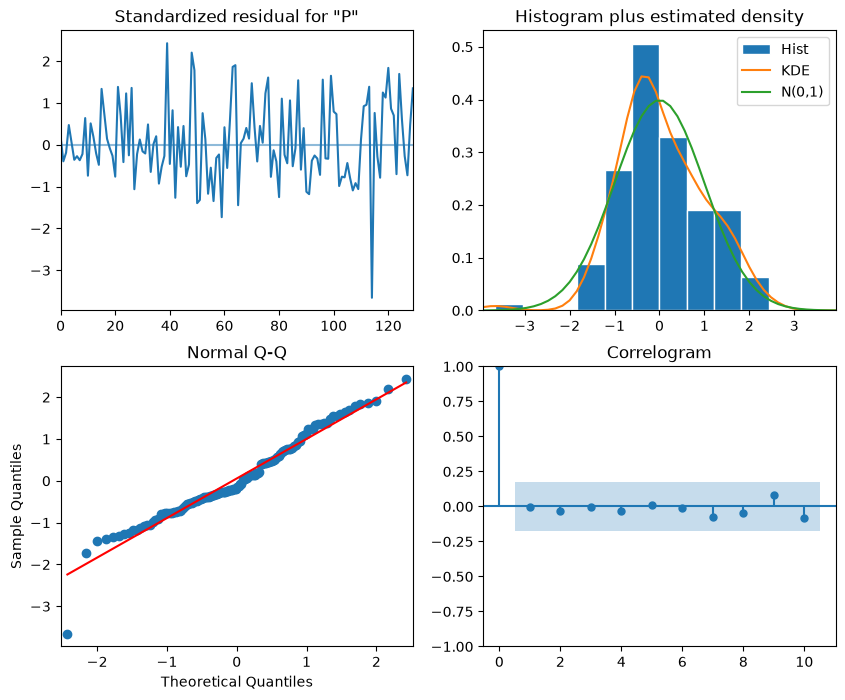

In [22]:
ARIMA_model_fit.plot_diagnostics(figsize=(10,8));

plt.savefig('figures/CH08_F09_peixeiro.png', dpi=300)

🛠️ **Prueba de Ljung-Box.** En versiones recientes de `statsmodels`, `acorr_ljungbox` devuelve una **tabla** (DataFrame) y no dos listas. El código original (`lbvalue, pvalue = acorr_ljungbox(...)`) ya no falla, pero imprime solo el texto `lb_pvalue` en lugar de los números: un error silencioso. Aquí guardamos la tabla completa y mostramos la columna de p-valores.

In [23]:
residuals = ARIMA_model_fit.resid

# 🛠️ Versión actualizada (statsmodels >= 0.13 devuelve un DataFrame)
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_df = acorr_ljungbox(residuals, lags=np.arange(1, 11, 1), return_df=True)

print(lb_df['lb_pvalue'])
print('\n¿Todos los p-valores > 0.05?', (lb_df['lb_pvalue'] > 0.05).all())

1     0.010481
2     0.035476
3     0.073356
4     0.101238
5     0.135898
6     0.192495
7     0.219193
8     0.284425
9     0.371841
10    0.317555
Name: lb_pvalue, dtype: float64

¿Todos los p-valores > 0.05? False


🔎 **Cómo leer Ljung-Box.** Hipótesis nula (H0): *los residuos NO están correlacionados* (son ruido blanco).
- **p-valor > 0.05 en todos los rezagos** → no rechazamos H0 → los residuos parecen ruido blanco → ✅ el modelo capturó la información útil.
- p-valor < 0.05 en algún rezago → queda estructura sin explicar → conviene probar otro orden del modelo.

⚠️ Ojo: aquí **queremos p-valores ALTOS**, al revés que en la prueba ADF (donde queremos p-valores bajos para declarar estacionariedad).

🔎 **Con este ARIMA(11,2,3), los p-valores de los rezagos 1 y 2 quedan por debajo de 0.05** (≈ 0.01 y 0.04 en nuestra ejecución): los residuos todavía tienen algo de correlación. Es una pista de que el modelo no capturó toda la estructura… la estacionalidad. Compáralo con el SARIMA más abajo.

🧭 Test = **los 12 meses de 1960**. Baseline naive estacional: repetir los 12 meses de 1959.

In [24]:
test = df.iloc[-12:]

test['naive_seasonal'] = df['Passengers'].iloc[120:132].values
test

,Month,Passengers,naive_seasonal
132,1960-01,417,360
133,1960-02,391,342
134,1960-03,419,406
135,1960-04,461,396
136,1960-05,472,420
137,1960-06,535,472
138,1960-07,622,548
139,1960-08,606,559
140,1960-09,508,463
141,1960-10,461,407


In [25]:
ARIMA_pred = ARIMA_model_fit.get_prediction(132, 143).predicted_mean

test['ARIMA_pred'] = ARIMA_pred
test

,Month,Passengers,naive_seasonal,ARIMA_pred
132,1960-01,417,360,422.331388
133,1960-02,391,342,410.649193
134,1960-03,419,406,461.838574
135,1960-04,461,396,457.788882
136,1960-05,472,420,481.662891
137,1960-06,535,472,531.049169
138,1960-07,622,548,606.144556
139,1960-08,606,559,615.452025
140,1960-09,508,463,525.629516
141,1960-10,461,407,467.148092


🧭 Ajustamos el mejor SARIMA: **SARIMA(2,1,1)(1,1,2)₁₂**. Compara: necesita muchos menos parámetros no estacionales que el ARIMA(11,2,3).

In [26]:
SARIMA_model = SARIMAX(train, order=(2,1,1), seasonal_order=(1,1,2,12), simple_differencing=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                                        SARIMAX Results                                        
Dep. Variable:                              Passengers   No. Observations:                  132
Model:             SARIMAX(2, 1, 1)x(1, 1, [1, 2], 12)   Log Likelihood                -439.122
Date:                                 Fri, 02 Oct 2026   AIC                            892.243
Time:                                         15:06:37   BIC                            911.697
Sample:                                              0   HQIC                           900.143
                                                 - 132                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2658      0.085    -14.903      0.000      -1.432      -1

🔎 **Cómo leer los 4 paneles de `plot_diagnostics`** (queremos que los residuos parezcan **ruido blanco**, es decir, error puramente aleatorio):
1. **Residuos estandarizados (arriba izq.):** deben oscilar alrededor de 0, sin tendencia y con varianza más o menos constante.
2. **Histograma + densidad (arriba der.):** debe parecerse a la campana normal (línea N(0,1)).
3. **Q-Q plot (abajo izq.):** los puntos deben caer sobre la línea roja diagonal. Si se curvan en los extremos, los residuos no son normales.
4. **Correlograma / ACF (abajo der.):** ninguna barra (salvo la del rezago 0) debe salir de la zona azul.

💡 Analogía: si el modelo es bueno, lo que “sobra” (los residuos) debe ser como el ruido de estática de un radio: no queda ninguna melodía escondida que el modelo no haya escuchado.

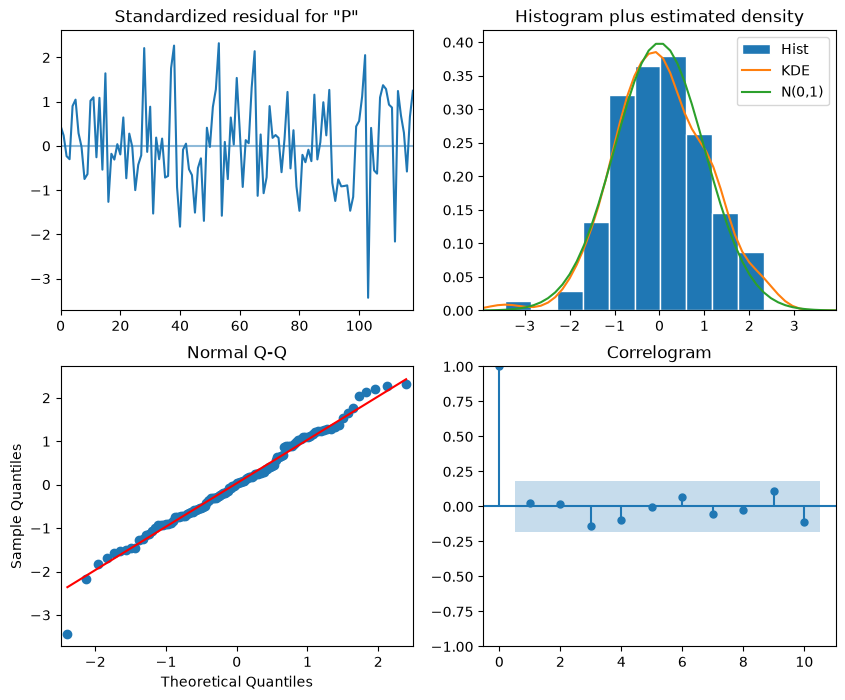

In [27]:
SARIMA_model_fit.plot_diagnostics(figsize=(10,8));

plt.savefig('figures/CH08_F12_peixeiro.png', dpi=300)

🛠️ **Cambio respecto al libro — prueba de Ljung-Box.** En versiones recientes de `statsmodels`, `acorr_ljungbox` devuelve una **tabla** (DataFrame) y no dos listas. El código original (`lbvalue, pvalue = acorr_ljungbox(...)`) ya no falla, pero imprime solo el texto `lb_pvalue` en lugar de los números: un error silencioso. Aquí guardamos la tabla completa y mostramos la columna de p-valores.

In [28]:
residuals = SARIMA_model_fit.resid

# 🛠️ Versión actualizada (statsmodels >= 0.13 devuelve un DataFrame)
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_df = acorr_ljungbox(residuals, lags=np.arange(1, 11, 1), return_df=True)

print(lb_df['lb_pvalue'])
print('\n¿Todos los p-valores > 0.05?', (lb_df['lb_pvalue'] > 0.05).all())

1     0.943718
2     0.690682
3     0.798859
4     0.874284
5     0.920016
6     0.944822
7     0.941823
8     0.951060
9     0.974090
10    0.893032
Name: lb_pvalue, dtype: float64

¿Todos los p-valores > 0.05? True


🔎 **Cómo leer Ljung-Box.** Hipótesis nula (H0): *los residuos NO están correlacionados* (son ruido blanco).
- **p-valor > 0.05 en todos los rezagos** → no rechazamos H0 → los residuos parecen ruido blanco → ✅ el modelo capturó la información útil.
- p-valor < 0.05 en algún rezago → queda estructura sin explicar → conviene probar otro orden del modelo.

⚠️ Ojo: aquí **queremos p-valores ALTOS**, al revés que en la prueba ADF (donde queremos p-valores bajos para declarar estacionariedad).

🔎 Con el SARIMA todos los p-valores quedan muy por encima de 0.05 → residuos compatibles con ruido blanco. ✅

In [29]:
SARIMA_pred = SARIMA_model_fit.get_prediction(132, 143).predicted_mean

test['SARIMA_pred'] = SARIMA_pred
test

,Month,Passengers,naive_seasonal,ARIMA_pred,SARIMA_pred
132,1960-01,417,360,422.331388,418.596632
133,1960-02,391,342,410.649193,399.657400
134,1960-03,419,406,461.838574,461.414164
135,1960-04,461,396,457.788882,451.537968
136,1960-05,472,420,481.662891,473.853928
137,1960-06,535,472,531.049169,538.772342
138,1960-07,622,548,606.144556,612.450605
139,1960-08,606,559,615.452025,624.645427
140,1960-09,508,463,525.629516,520.237418
141,1960-10,461,407,467.148092,462.960814


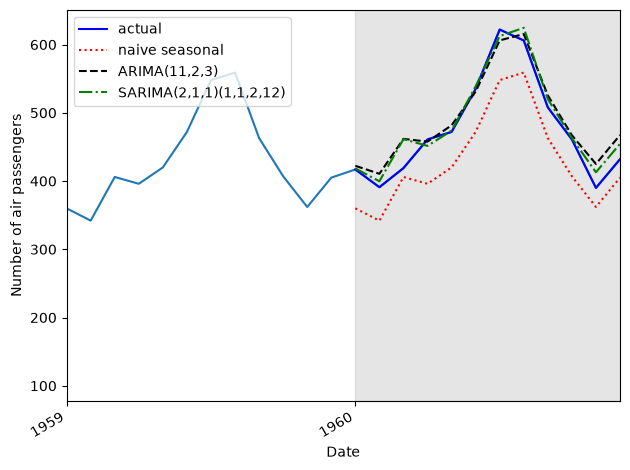

In [30]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
ax.plot(test['Passengers'], 'b-', label='actual')
ax.plot(test['naive_seasonal'], 'r:', label='naive seasonal')
ax.plot(test['ARIMA_pred'], 'k--', label='ARIMA(11,2,3)')
ax.plot(test['SARIMA_pred'], 'g-.', label='SARIMA(2,1,1)(1,1,2,12)')

ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')
ax.axvspan(132, 143, color='#808080', alpha=0.2)

ax.legend(loc=2)

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))
ax.set_xlim(120, 143)

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH08_F13_peixeiro.png', dpi=300)

In [31]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [32]:
mape_naive_seasonal = mape(test['Passengers'], test['naive_seasonal'])
mape_ARIMA = mape(test['Passengers'], test['ARIMA_pred'])
mape_SARIMA = mape(test['Passengers'], test['SARIMA_pred'])

print(mape_naive_seasonal, mape_ARIMA, mape_SARIMA)

9.987532920823485 3.841305062456637 2.863946467882572


🔎 Resultados (nuestra ejecución ≈ libro): naive estacional ≈ 10.0 %, ARIMA ≈ 3.8 %, **SARIMA ≈ 2.9 %**. Modelar la estacionalidad explícitamente gana, y con un modelo más pequeño.

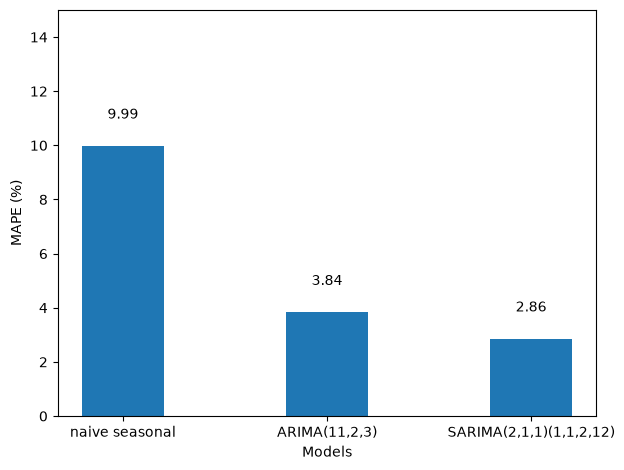

In [33]:
fig, ax = plt.subplots()

x = ['naive seasonal', 'ARIMA(11,2,3)', 'SARIMA(2,1,1)(1,1,2,12)']
y = [mape_naive_seasonal, mape_ARIMA, mape_SARIMA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 15)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(round(value,2)), ha='center')

plt.tight_layout()

plt.savefig('figures/CH08_F14_peixeiro.png', dpi=300)

---
## ✅ Resumen
| Modelo | Idea | MAPE (1960) |
|---|---|---|
| Naive estacional | repetir 1959 | ≈ 10 % |
| ARIMA(11,2,3) | memoria larga “a la fuerza” | ≈ 3.8 % |
| **SARIMA(2,1,1)(1,1,2)₁₂** | **estacionalidad explícita** | **≈ 2.9 %** |

- Detecta estacionalidad con el gráfico y con **STL**; *m* sale de la frecuencia de los datos.
- Diferencia estacional = $y_t - y_{t-m}$ (¡no `np.diff(n=m)`!).
- El procedimiento general es el mismo; solo agregamos P, D, Q, m a la búsqueda.

### 🏠 Ejercicios para casa
`CH08_exercises_solution.ipynb`: aplica SARIMA a la serie de J&J (m = 4) y compáralo con el ARIMA del Capítulo 7.

### 🧠 Autoevaluación
- ¿Qué valor de *m* usarías para ventas diarias con patrón semanal? ¿Y para consumo eléctrico horario con patrón diario?
- ¿Por qué el ARIMA necesitó *p* = 11?
